In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [10]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [12]:
#load money market rate data
rates = pd.read_excel("/content/gdrive/MyDrive/moneymarket/ref_rates.xlsx", sheet_name="data")

rates["date"] = pd.to_datetime(rates["date"])

rates = rates.sort_values("date")

rates = rates.set_index("date")

print(rates.head())

            DTB3   DFF  SOFR
date                        
2018-01-01   NaN  1.33   NaN
2018-01-02  1.42  1.42   NaN
2018-01-03  1.39  1.42   NaN
2018-01-04  1.39  1.42   NaN
2018-01-05  1.37  1.42   NaN


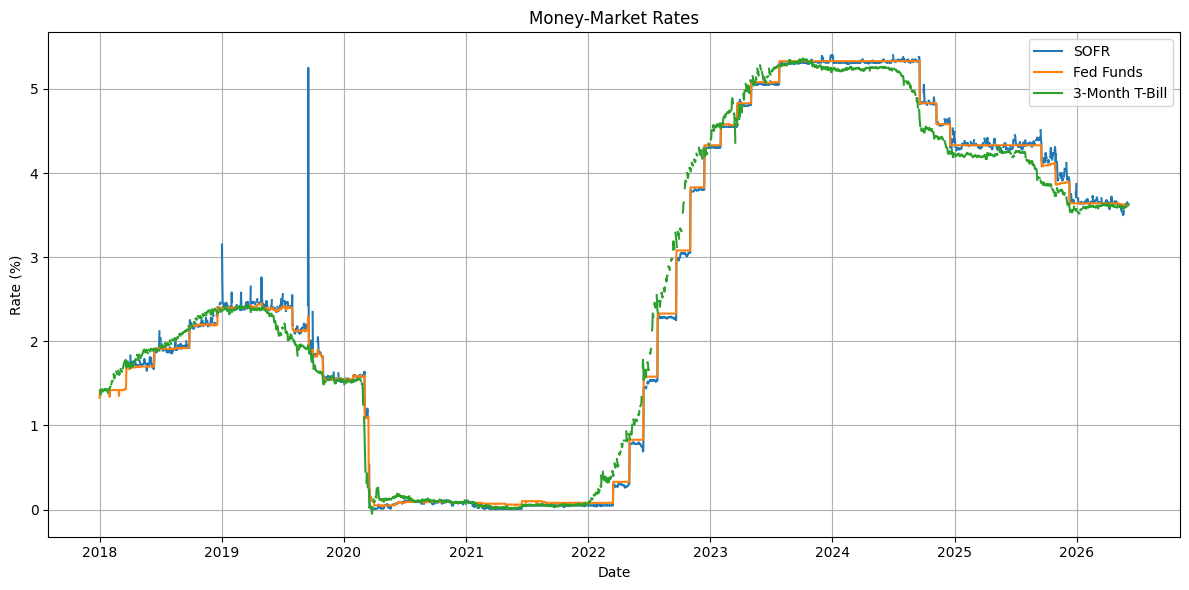

In [14]:
#Plotting the 3 money market rates

plt.figure(figsize=(12, 6))

plt.plot(rates.index, rates["SOFR"], label="SOFR")
plt.plot(rates.index, rates["DFF"], label="Fed Funds")
plt.plot(rates.index, rates["DTB3"], label="3-Month T-Bill")

plt.title("Money-Market Rates")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
#Correlating levels
#Keep only dates where all three rates are available
levels = rates[["SOFR", "DFF", "DTB3"]].dropna()

level_corr = levels.corr()

print("\nCorrelation of Levels:")
print(level_corr)


Correlation of Levels:
          SOFR       DFF      DTB3
SOFR  1.000000  0.999091  0.992898
DFF   0.999091  1.000000  0.994704
DTB3  0.992898  0.994704  1.000000


In [16]:
#Day-over-day changes
differences = levels.diff().dropna()

difference_corr = differences.corr()

print("\nCorrelation of Day-over-Day Differences:")
print(difference_corr)

#SOFR autoregression

sofr = rates["SOFR"].dropna().copy()

# Create one-day lag
sofr_data = pd.DataFrame({
    "SOFR": sofr,
    "SOFR_lag": sofr.shift(1)
}).dropna()

#y: Dependent var; x: ind. var
y = sofr_data["SOFR"]
X = sofr_data["SOFR_lag"]

# Add intercept
X = sm.add_constant(X)

#Regression
sofr_model = sm.OLS(y, X).fit()

print("\nSOFR Autoregression:")
print(sofr_model.summary())

print("\nSOFR Beta:")
print(sofr_model.params["SOFR_lag"])

print("\nSOFR R-squared:")
print(sofr_model.rsquared)


Correlation of Day-over-Day Differences:
          SOFR       DFF      DTB3
SOFR  1.000000  0.496540  0.037454
DFF   0.496540  1.000000  0.007996
DTB3  0.037454  0.007996  1.000000

SOFR Autoregression:
                            OLS Regression Results                            
Dep. Variable:                   SOFR   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 6.782e+05
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:38:16   Log-Likelihood:                 1668.3
No. Observations:                2041   AIC:                            -3333.
Df Residuals:                    2039   BIC:                            -3321.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
      

In [17]:
spy_returns = pd.read_excel("/content/gdrive/MyDrive/moneymarket/spy_data_daily.xlsx", sheet_name="total returns")
spy_prices = pd.read_excel("/content/gdrive/MyDrive/moneymarket/spy_data_daily.xlsx", sheet_name="prices")

# Convert dates to datetime
spy_returns["date"] = pd.to_datetime(spy_returns["date"])
spy_prices["date"] = pd.to_datetime(spy_prices["date"])

spy_returns = spy_returns.sort_values("date")
spy_prices = spy_prices.sort_values("date")

spy_returns = spy_returns.set_index("date")
spy_prices = spy_prices.set_index("date")

In [18]:
#SPY return autoregression
returns = spy_returns["SPY"].dropna()

# Create one-day lag
return_data = pd.DataFrame({
    "return": returns,
    "return_lag": returns.shift(1)
}).dropna()

#y= Dependent var; x: indep.
y = return_data["return"]
X = return_data["return_lag"]

# Add intercept
X = sm.add_constant(X)

# Run regression
spy_return_model = sm.OLS(y, X).fit()

print("\n========================================")
print("SPY RETURN AUTOREGRESSION")
print("========================================")

print(spy_return_model.summary())

print("\nSPY Return Beta:")
print(spy_return_model.params["return_lag"])

print("\nSPY Return R-squared:")
print(spy_return_model.rsquared)


#SPY Price autoregression

prices = spy_prices["SPY"].dropna()

# Create one-day lag
price_data = pd.DataFrame({
    "price": prices,
    "price_lag": prices.shift(1)
}).dropna()

#y= Dependent var; x: indep.
y = price_data["price"]
X = price_data["price_lag"]

# Add intercept
X = sm.add_constant(X)

# Run regression
spy_price_model = sm.OLS(y, X).fit()

print("\n========================================")
print("SPY PRICE AUTOREGRESSION")
print("========================================")

print(spy_price_model.summary())

print("\nSPY Price Beta:")
print(spy_price_model.params["price_lag"])

print("\nSPY Price R-squared:")
print(spy_price_model.rsquared)


SPY RETURN AUTOREGRESSION
                            OLS Regression Results                            
Dep. Variable:                 return   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     56.45
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           6.38e-14
Time:                        20:50:48   Log-Likelihood:                 24669.
No. Observations:                8164   AIC:                        -4.933e+04
Df Residuals:                    8162   BIC:                        -4.932e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005    